Project Type: Multi-Label Classification

Project Title: OTT Content Moderation Tagging System

Introduction

Online video platforms and OTT services must apply appropriate moderation and safety tags to content for
compliance, parental controls, and user safety. A single content item may require multiple tags at the same time
(for example, content may include violence, strong language, and substance use together). This makes the task a
multi-label classification problem: one input record can map to multiple output labels simultaneously

Problem Statement

Build a Machine Learning model that predicts the appropriate moderation and sensitivity tags for each content
item using structured metadata and computed signals. The model must support multi-label output (predicting
multiple labels for a single record)

Expected Outcome

At the end of this project, students should be able to: Frame a business requirement as a multi-label ML problem.
Perform end-to-end EDA, preprocessing, and feature engineering on structured data. Train and compare
multi-label modeling approaches. Evaluate models using multi-label metrics and select the best model based on
evidence

Step-by-Step Workflow

Step 1: Data Understanding

Inspect the dataset structure, data types, missing values, and basic statistics. Document observations and
questions to validate during analysis

Step 2: Data Cleaning

Handle missing values, inconsistent entries, and outliers where applicable. Ensure each record is valid and usable
for modeling

Step 3: Exploratory Data Analysis (EDA)

Perform thorough EDA across the entire dataset: Univariate analysis for every feature (distribution, central
tendency, spread, outliers). Bivariate analysis across meaningful feature pairs (relationships, patterns, potential
dependencies). Target exploration: analyze label frequencies, label imbalance, and the number of labels per
record. Label co-occurrence analysis: identify which labels frequently occur together. Multivariate analysis:
correlation and interaction analysis for numerical features. Note: Students must provide their own interpretations
and insights based on analysis.

Step 4: Multi-Label Target Preparation

Prepare the label matrix (multi-hot encoding) for training. Ensure the pipeline supports multiple labels per row.

Step 5: Preprocessing Pipeline

Prepare transformations for numeric, categorical, and binary features (encoding and scaling where required). Use
a reproducible pipeline approach

Step 6: Train-Test Split

Split the data into training and testing sets. Ensure the split preserves label characteristics as much as possible.


Step 7: Model Building (Multi-Label Approaches)

Implement and compare multiple multi-label strategies, such as: Binary Relevance Classifier Chains Label
Powerset Train multiple base estimators (for example, linear models and tree-based models) and compare
performance

Step 8: Model Evaluation (Multi-Label Metrics)


Evaluate and compare models using multi-label metrics such as: Hamming Loss Jaccard Score Micro / Macro F1
Score Subset Accuracy Also include per-label performance where appropriate

Step 9: Model Selection


Select the best-performing approach based on evaluation metrics, stability, and interpretability. Provide
justification

Step 10: Final Reporting


Submit a complete report including EDA, preprocessing, modeling approach, evaluation results, and conclusions.

Data Dictionary


The table below describes the available features and target labels in the dataset.
Field Name Type Description
content_duration Numeric Total content duration (minutes).
number_of_fight_scenes Numeric Count of fight/action scenes identified.
weapon_presence_count Numeric Count of weapon presence occurrences.
night_scene_ratio Numeric Proportion of scenes occurring at night (0–1).
number_of_curse_words Numeric Count of profanity/curse occurrences detected.
smoking_scene_count Numeric Count of smoking-related scenes.
alcohol_scene_count Numeric Count of alcohol-related scenes.
blood_visibility_score Numeric Intensity score for visible blood (0–100).
intimacy_scene_duration Numeric Duration of intimate scenes (minutes).
scream_frequency Numeric Count/intensity of scream-like audio events.
loud_noise_ratio Numeric Proportion of high-intensity audio segments (0–1).
disturbing_background_music Binary Whether disturbing background music is present (0/1).
protest_scene_count Numeric Count of protest/political rally scenes.
religious_symbol_presence Binary Whether religious symbols are present (0/1).
crying_scene_duration Numeric Duration of crying/distress scenes (minutes).
camera_shake_index Numeric Camera shake intensity index (0–100).
audience_age_rating Categorical Content rating category (e.g., U / UA / A).
violence_flag Label (0/1) Indicates presence of violence-related content.
adult_content_flag Label (0/1) Indicates presence of adult/intimate content.
substance_abuse_flag Label (0/1) Indicates presence of substance use (smoking/alcohol).
strong_language_flag Label (0/1) Indicates strong language/profanity.
self_harm_flag Label (0/1) Indicates self-harm related signals.
disturbing_visuals_flag Label (0/1) Indicates disturbing imagery/visuals.
political_sensitivity_flag Label (0/1) Indicates political sensitivity signals.
religious_sensitivity_flag Label (0/1) Indicates religious sensitivity signals

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Downloads/ott_content_moderation_multilabel_dataset.csv")

In [3]:
df.head()

,content_duration,number_of_fight_scenes,weapon_presence_count,night_scene_ratio,number_of_curse_words,smoking_scene_count,alcohol_scene_count,blood_visibility_score,intimacy_scene_duration,scream_frequency,...,camera_shake_index,audience_age_rating,violence_flag,adult_content_flag,substance_abuse_flag,strong_language_flag,self_harm_flag,disturbing_visuals_flag,political_sensitivity_flag,religious_sensitivity_flag
0,67,2,2,0.319,3,6,7,19,12.5,3,...,27,UA,0,1,1,0,0,0,0,0
1,48,5,3,0.508,0,0,1,32,1.5,4,...,19,UA,1,0,0,0,0,0,0,0
2,24,3,3,0.388,2,0,1,28,0.9,2,...,24,U,0,1,0,0,0,0,0,0
3,98,8,6,0.558,6,2,0,47,12.9,5,...,41,A,1,1,0,1,1,1,1,1
4,45,3,2,0.366,0,1,0,28,0.0,1,...,28,U,1,1,0,0,0,1,0,0


In [4]:
df.describe()

,content_duration,number_of_fight_scenes,weapon_presence_count,night_scene_ratio,number_of_curse_words,smoking_scene_count,alcohol_scene_count,blood_visibility_score,intimacy_scene_duration,scream_frequency,...,crying_scene_duration,camera_shake_index,violence_flag,adult_content_flag,substance_abuse_flag,strong_language_flag,self_harm_flag,disturbing_visuals_flag,political_sensitivity_flag,religious_sensitivity_flag
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,51.018750,3.571583,2.496583,0.424276,5.067833,1.996750,2.319833,28.256833,4.427325,2.022500,...,3.453008,27.813083,0.380833,0.476333,0.529167,0.462250,0.347833,0.374500,0.466083,0.462167
std,21.669226,2.743964,2.142398,0.131300,4.976190,1.983238,2.321886,18.144218,4.633148,1.916151,...,3.647236,14.595943,0.485612,0.499460,0.499169,0.498594,0.476303,0.484014,0.498869,0.498587
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,1.000000,0.334000,1.000000,0.000000,0.000000,15.000000,0.500000,0.750000,...,0.100000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,3.000000,2.000000,0.417000,4.000000,2.000000,2.000000,25.000000,3.200000,2.000000,...,2.500000,26.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,66.000000,5.000000,4.000000,0.507000,8.000000,3.000000,4.000000,38.000000,6.700000,3.000000,...,5.400000,36.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,135.000000,17.000000,14.000000,0.950000,33.000000,14.000000,15.000000,100.000000,31.700000,15.000000,...,25.400000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.isnull().sum()

content_duration               0
number_of_fight_scenes         0
weapon_presence_count          0
night_scene_ratio              0
number_of_curse_words          0
smoking_scene_count            0
alcohol_scene_count            0
blood_visibility_score         0
intimacy_scene_duration        0
scream_frequency               0
loud_noise_ratio               0
disturbing_background_music    0
protest_scene_count            0
religious_symbol_presence      0
crying_scene_duration          0
camera_shake_index             0
audience_age_rating            0
violence_flag                  0
adult_content_flag             0
substance_abuse_flag           0
strong_language_flag           0
self_harm_flag                 0
disturbing_visuals_flag        0
political_sensitivity_flag     0
religious_sensitivity_flag     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   content_duration             12000 non-null  int64  
 1   number_of_fight_scenes       12000 non-null  int64  
 2   weapon_presence_count        12000 non-null  int64  
 3   night_scene_ratio            12000 non-null  float64
 4   number_of_curse_words        12000 non-null  int64  
 5   smoking_scene_count          12000 non-null  int64  
 6   alcohol_scene_count          12000 non-null  int64  
 7   blood_visibility_score       12000 non-null  int64  
 8   intimacy_scene_duration      12000 non-null  float64
 9   scream_frequency             12000 non-null  int64  
 10  loud_noise_ratio             12000 non-null  float64
 11  disturbing_background_music  12000 non-null  int64  
 12  protest_scene_count          12000 non-null  int64  
 13  religious_symbol

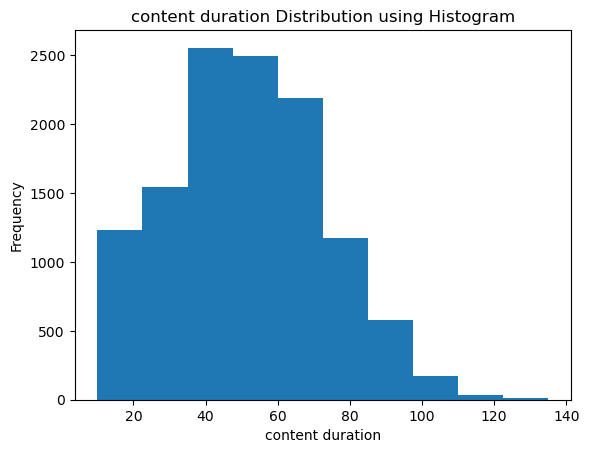

In [9]:
plt.hist(df["content_duration"])
plt.title("content duration Distribution using Histogram")
plt.xlabel("content duration")
plt.ylabel("Frequency")
plt.show()

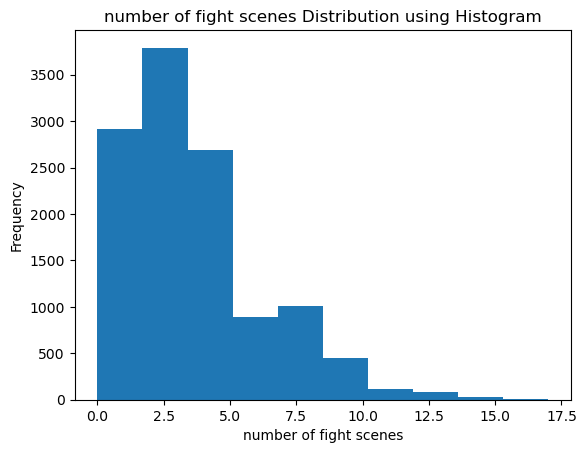

In [10]:
plt.hist(df["number_of_fight_scenes"])
plt.title("number of fight scenes Distribution using Histogram")
plt.xlabel("number of fight scenes")
plt.ylabel("Frequency")
plt.show()

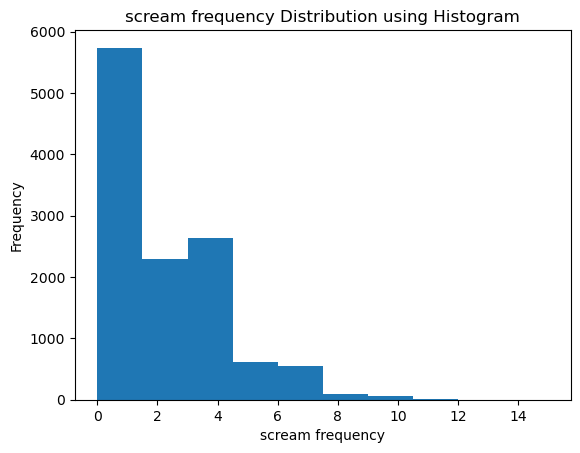

In [11]:
plt.hist(df["scream_frequency"])
plt.title("scream frequency Distribution using Histogram")
plt.xlabel("scream frequency")
plt.ylabel("Frequency")
plt.show()

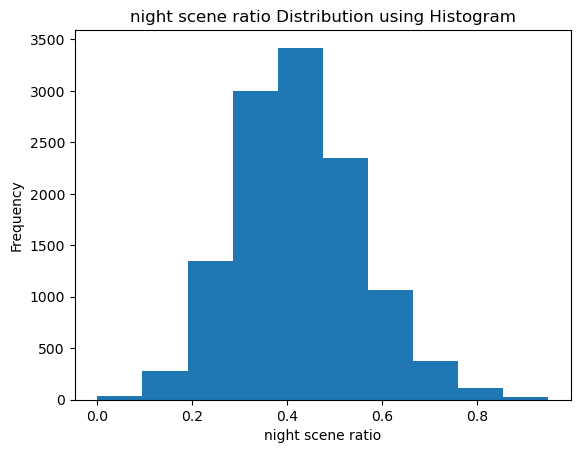

In [12]:
plt.hist(df["night_scene_ratio"])
plt.title("night scene ratio Distribution using Histogram")
plt.xlabel("night scene ratio")
plt.ylabel("Frequency")
plt.show()

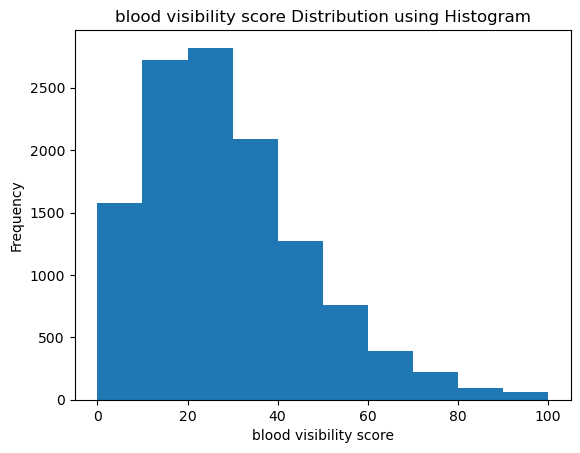

In [14]:
plt.hist(df["blood_visibility_score"])
plt.title("blood visibility score Distribution using Histogram")
plt.xlabel("blood visibility score")
plt.ylabel("Frequency")
plt.show()

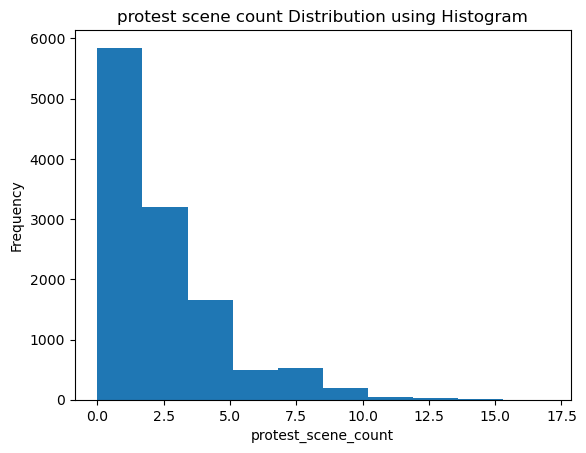

In [16]:
plt.hist(df["protest_scene_count"])
plt.title("protest scene count Distribution using Histogram")
plt.xlabel("protest_scene_count")
plt.ylabel("Frequency")
plt.show()

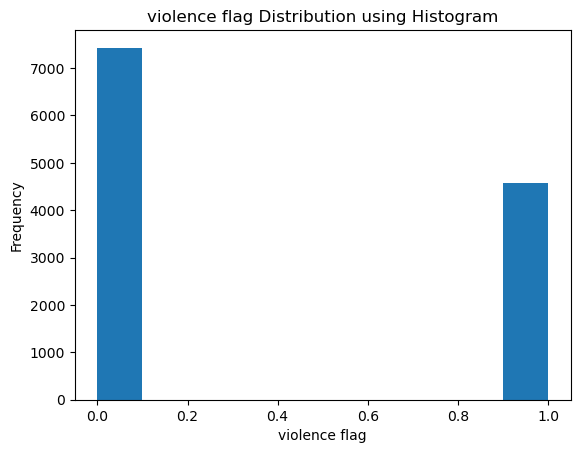

In [17]:
plt.hist(df["violence_flag"])
plt.title("violence flag Distribution using Histogram")
plt.xlabel("violence flag")
plt.ylabel("Frequency")
plt.show()

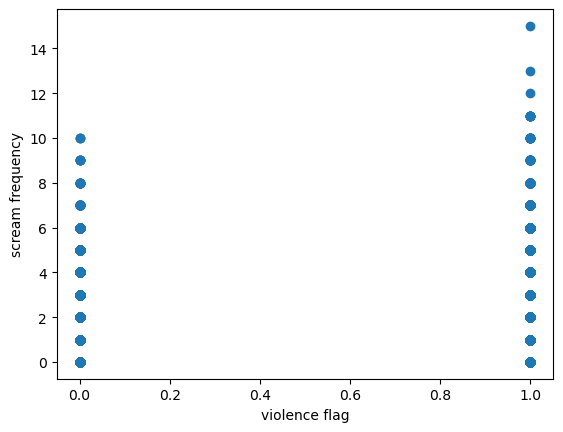

In [20]:
plt.scatter(df["violence_flag"],df["scream_frequency"])
plt.xlabel("violence flag")
plt.ylabel("scream frequency")
plt.show()

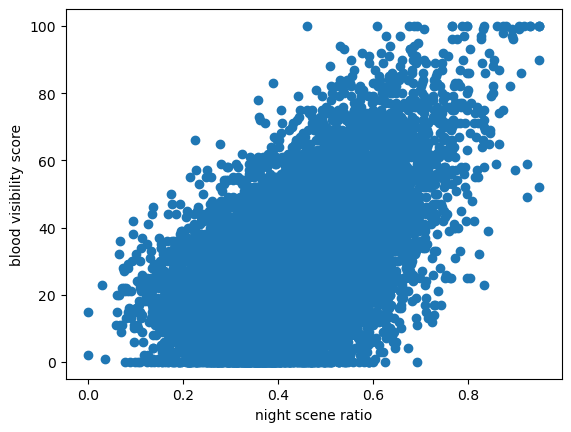

In [19]:
plt.scatter(df["night_scene_ratio"],df["blood_visibility_score"])
plt.xlabel("night scene ratio")
plt.ylabel("blood visibility score")
plt.show()

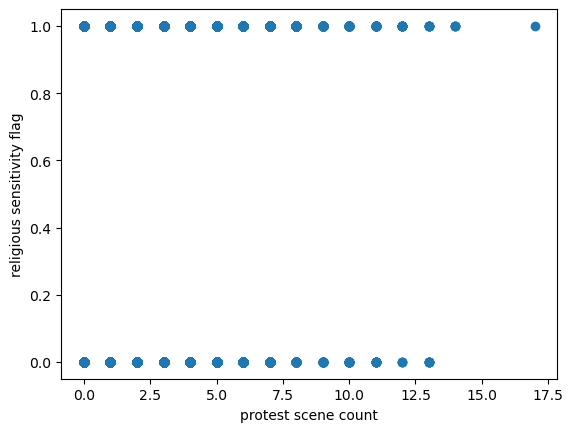

In [21]:
plt.scatter(df["protest_scene_count"],df["religious_sensitivity_flag"])
plt.xlabel("protest scene count")
plt.ylabel("religious sensitivity flag")
plt.show()

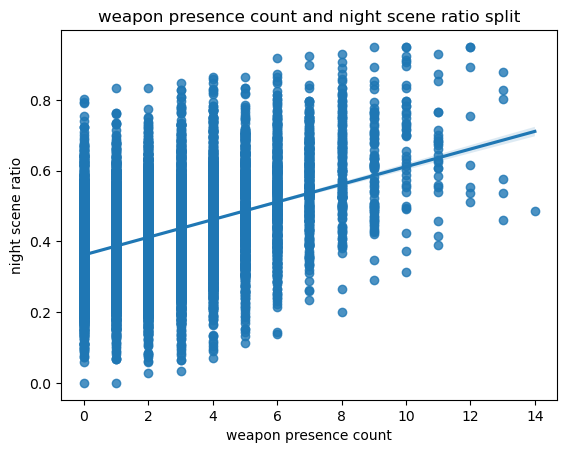

In [23]:
sns.regplot(x="weapon_presence_count",y="night_scene_ratio",data=df)
plt.title("weapon presence count and night scene ratio split")
plt.xlabel("weapon presence count")
plt.ylabel("night scene ratio")
plt.show()

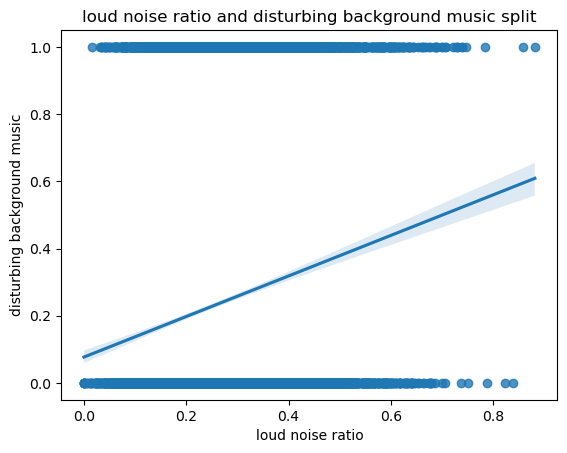

In [24]:
sns.regplot(x="loud_noise_ratio",y="disturbing_background_music",data=df)
plt.title("loud noise ratio and disturbing background music split")
plt.xlabel("loud noise ratio")
plt.ylabel("disturbing background music")
plt.show()

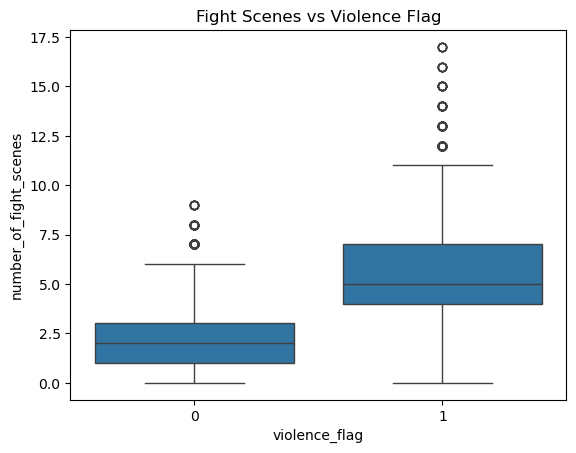

In [26]:
sns.boxplot(x='violence_flag', y='number_of_fight_scenes', data=df)
plt.title("Fight Scenes vs Violence Flag")
plt.show()

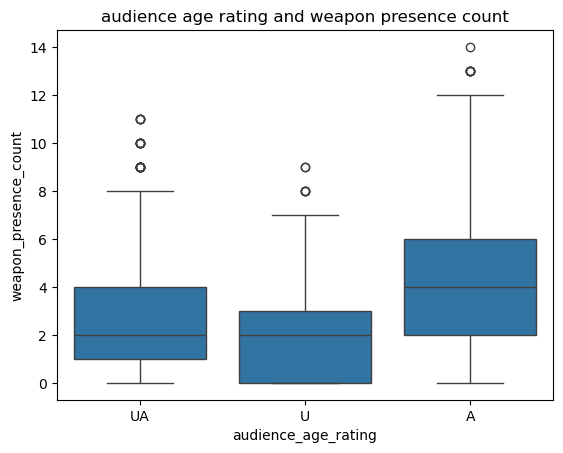

In [27]:
sns.boxplot(x="audience_age_rating",y="weapon_presence_count",data=df)
plt.title('audience age rating and weapon presence count')
plt.show()

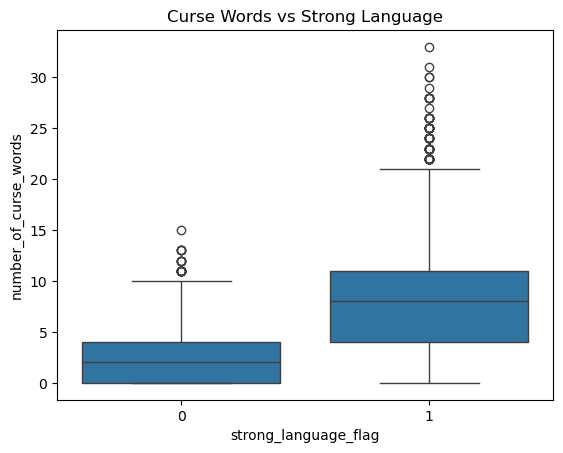

In [28]:
sns.boxplot(x='strong_language_flag', y='number_of_curse_words', data=df)
plt.title("Curse Words vs Strong Language")
plt.show()

In [29]:
numerical_col=df.select_dtypes(include=['int64','float64'])

In [31]:
corr=numerical_col.corr()
corr

,content_duration,number_of_fight_scenes,weapon_presence_count,night_scene_ratio,number_of_curse_words,smoking_scene_count,alcohol_scene_count,blood_visibility_score,intimacy_scene_duration,scream_frequency,...,crying_scene_duration,camera_shake_index,violence_flag,adult_content_flag,substance_abuse_flag,strong_language_flag,self_harm_flag,disturbing_visuals_flag,political_sensitivity_flag,religious_sensitivity_flag
content_duration,1.000000,0.144680,0.158150,0.122511,0.047209,0.021531,0.023258,0.159610,0.040529,0.076481,...,0.032102,0.141008,0.143908,0.043567,0.022328,0.042595,0.040105,0.048461,0.113554,0.021105
number_of_fight_scenes,0.144680,1.000000,0.593154,0.422076,0.159715,0.084464,0.062438,0.607871,0.128344,0.307846,...,0.140993,0.561541,0.567893,0.141616,0.063732,0.168702,0.120979,0.189464,0.016568,0.009198
weapon_presence_count,0.158150,0.593154,1.000000,0.406958,0.156454,0.078132,0.069715,0.582841,0.122796,0.289983,...,0.124805,0.542710,0.561593,0.146854,0.052190,0.151083,0.123836,0.180139,0.103913,0.027303
night_scene_ratio,0.122511,0.422076,0.406958,1.000000,0.130690,0.083162,0.065889,0.532951,0.140216,0.471663,...,0.382758,0.505377,0.411514,0.152778,0.070422,0.123964,0.319583,0.366320,0.022627,0.005298
number_of_curse_words,0.047209,0.159715,0.156454,0.130690,1.000000,0.116424,0.101896,0.177369,0.229044,0.106953,...,0.063841,0.165105,0.175234,0.186278,0.065803,0.573575,0.076508,0.084019,0.019593,0.000094
smoking_scene_count,0.021531,0.084464,0.078132,0.083162,0.116424,1.000000,0.617995,0.093106,0.417711,0.086119,...,0.072604,0.091530,0.075965,0.296878,0.485546,0.062961,0.059161,0.061695,-0.014810,-0.007499
alcohol_scene_count,0.023258,0.062438,0.069715,0.065889,0.101896,0.617995,1.000000,0.075727,0.371889,0.064094,...,0.056270,0.079657,0.065292,0.260496,0.494143,0.054991,0.052224,0.043951,-0.008550,0.008222
blood_visibility_score,0.159610,0.607871,0.582841,0.532951,0.177369,0.093106,0.075727,1.000000,0.162074,0.533053,...,0.391108,0.662616,0.611899,0.193086,0.079623,0.182859,0.330742,0.407995,0.024450,0.014921
intimacy_scene_duration,0.040529,0.128344,0.122796,0.140216,0.229044,0.417711,0.371889,0.162074,1.000000,0.135866,...,0.110235,0.151252,0.140292,0.559738,0.261477,0.089184,0.121459,0.119032,0.011317,0.006370
scream_frequency,0.076481,0.307846,0.289983,0.471663,0.106953,0.086119,0.064094,0.533053,0.135866,1.000000,...,0.639565,0.519653,0.322090,0.156432,0.071982,0.105917,0.523700,0.532771,0.014835,0.006736


<Axes: >

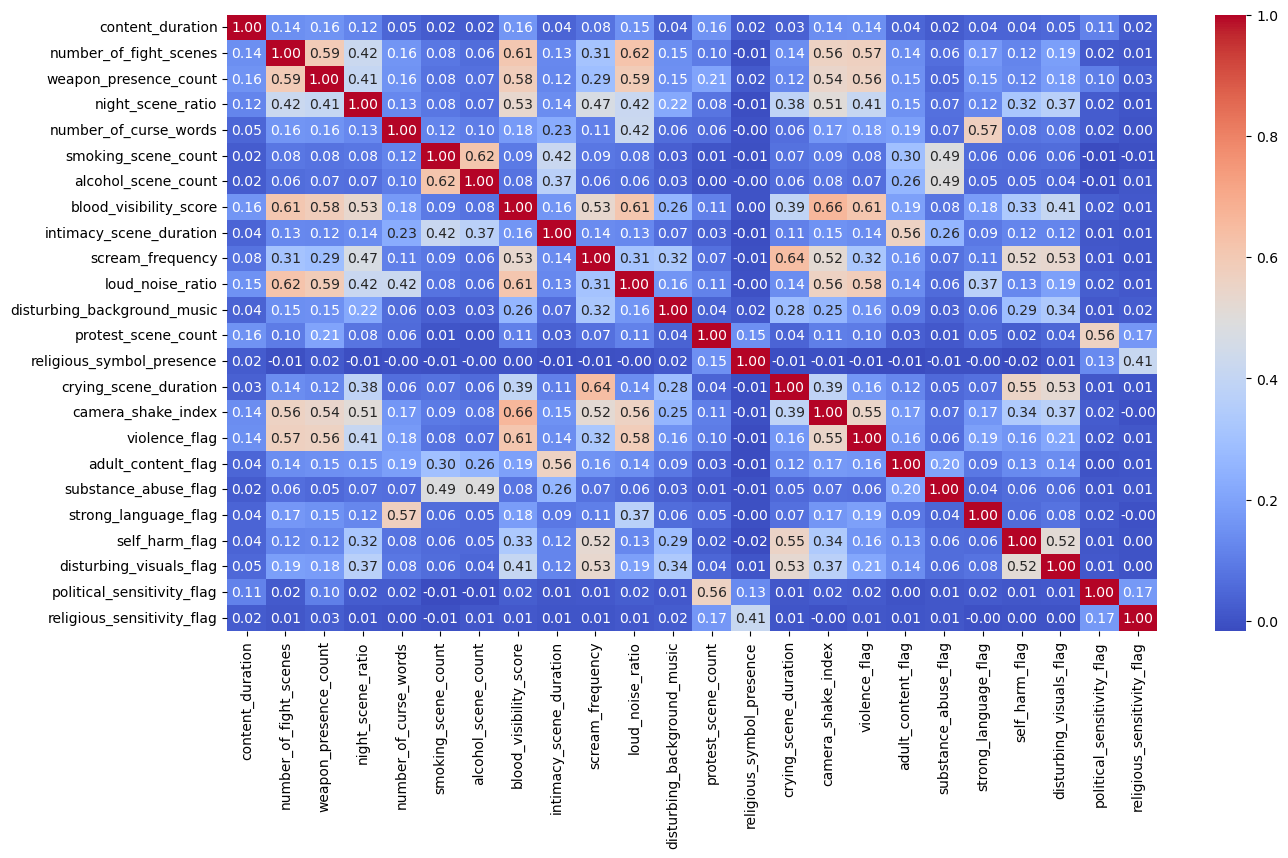

In [33]:
plt.figure(figsize=(15,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
X = df.drop(columns=labels, axis=1)
y = df[labels]

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [51]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classifier:
Accuracy: 0.15208333333333332

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81       958
           1       0.82      0.68      0.74      1154
           2       0.80      0.69      0.74      1302
           3       0.82      0.70      0.76      1117
           4       0.81      0.57      0.67       848
           5       0.81      0.59      0.68       908
           6       0.82      0.62      0.71      1132
           7       0.70      0.53      0.61      1109

   micro avg       0.81      0.64      0.72      8528
   macro avg       0.81      0.64      0.71      8528
weighted avg       0.81      0.64      0.72      8528
 samples avg       0.72      0.59      0.62      8528



C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,accuracy_score

In [57]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Classifier:
Accuracy: 0.04666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.69      0.70       958
           1       0.67      0.67      0.67      1154
           2       0.65      0.63      0.64      1302
           3       0.66      0.69      0.67      1117
           4       0.59      0.58      0.58       848
           5       0.60      0.58      0.59       908
           6       0.61      0.60      0.61      1132
           7       0.51      0.52      0.52      1109

   micro avg       0.63      0.62      0.62      8528
   macro avg       0.63      0.62      0.62      8528
weighted avg       0.63      0.62      0.62      8528
 samples avg       0.59      0.59      0.55      8528



C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.multioutput import MultiOutputClassifier

In [72]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

C:\Users\om\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:02:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier:
Accuracy: 0.13291666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.76      0.81       958
           1       0.77      0.70      0.73      1154
           2       0.77      0.69      0.73      1302
           3       0.77      0.71      0.74      1117
           4       0.76      0.64      0.69       848
           5       0.77      0.63      0.69       908
           6       0.76      0.66      0.71      1132
           7       0.67      0.54      0.60      1109

   micro avg       0.77      0.67      0.71      8528
   macro avg       0.77      0.67      0.71      8528
weighted avg       0.77      0.67      0.71      8528
 samples avg       0.70      0.62      0.62      8528



C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [75]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
lr_model = MultiOutputClassifier(RandomForestClassifier())
lr_model.fit(X_train, y_train)
y_pred= lr_model.predict(X_test)
y_prob=lr_model.predict_proba(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred,target_names=labels))

Accuracy Score: 0.15416666666666667

Classification Report:
                             precision    recall  f1-score   support

             violence_flag       0.89      0.75      0.82       958
        adult_content_flag       0.81      0.69      0.74      1154
      substance_abuse_flag       0.81      0.68      0.74      1302
      strong_language_flag       0.82      0.70      0.76      1117
            self_harm_flag       0.79      0.61      0.69       848
   disturbing_visuals_flag       0.81      0.63      0.71       908
political_sensitivity_flag       0.80      0.64      0.71      1132
religious_sensitivity_flag       0.74      0.51      0.60      1109

                 micro avg       0.81      0.65      0.72      8528
                 macro avg       0.81      0.65      0.72      8528
              weighted avg       0.81      0.65      0.72      8528
               samples avg       0.72      0.60      0.63      8528



C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
